In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import subprocess
import classy
print("classy imported from: \n",classy.__file__)
# import necessary modules
# uncomment to get plots displayed in notebook
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from scipy.interpolate import interp2d
import os
import math
from scipy.interpolate import UnivariateSpline
import csv

classy imported from: 
 /home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10/classy.cpython-310-x86_64-linux-gnu.so


In [2]:
# Cosmological parameters:
z_max_rec = 1e6
a_ini_over_a_today_default = 1e-14
z_max_pk = 1e10       # highest redshift involved
z_max_thermo = 5e7
start_tau_k = 0.00001
k_per_decade = 250     # number of k values, controls final resolution
k_min_tau0 = .001       # this value controls the minimum k value in the figure (it is k_min * tau0)
P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc
tau_num_early = 1000   # number of conformal time values before recombination, controls final resolution
tau_num_late = 500     # number of conformal time values after recombination, controls final resolution
                        # first value of conformal time in Mpc
h = 0.6732117

In [3]:
def get_sound_speeds(frac_dmde, g_scf, m_scf, phi_scf_ini): #(0.6732117, 0.4, 0.5, 0.1)
    common_settings = {# which output? transfer functions only
                   'output':'mTk',
                   # LambdaCDM parameters
                   'h':0.6732117,
                   'omega_b':0.022032,
                   'omega_cdm':0.1201075,
                   'frac_dmde': frac_dmde,
                   'g_scf': g_scf,
                   'm_scf': m_scf,
                   'phi_scf_ini': phi_scf_ini,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'Omega_k': 0.,
                   'A_s': 2.215e-9,
                  'n_s': 0.9619,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    ###############
    #
    # call CLASS
    #
    ###############
    # print("Starting CLASS\n")

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    # print("CLASS is done!\n")

    background = M_pre.get_background() # load background table                                                                                                                           
    #print background.viewkeys()                                                                                                                                                          
    background_tau = background['conf. time [Mpc]'] # read conformal times in background table       
    background_z = background['z'] # read redshift
    background_tau_at_z = interp1d(background_z,background_tau)

    tau_ini = background_tau_at_z(z_max_pk)
    # print(tau_ini)
    times = M_pre.get_current_derived_parameters(['tau_rec','conformal_age'])
    tau_rec=times['tau_rec']
    tau_0 = times['conformal_age']
    tau1 = np.logspace(math.log10(tau_ini),math.log10(5*tau_rec),tau_num_early)
    tau2 = np.logspace(math.log10(5*tau_rec),math.log10(tau_0),tau_num_late)[1:]
    tau2[-1]=tau_0
    tau2[-1] *= 0.999999 # this tiny shift avoids interpolation errors
    tau= np.concatenate((tau1,tau2))
    tau_num = len(tau)

    background_z = background['z'] # read redshift
    background_aH = background['H [1/Mpc]']/(1.+background['z'])

    background_rho_cdm = background['(.)rho_cdm'] # read rho cdm in background table
    background_rho_nu = background['(.)rho_ur'] # read rho nu in background table

    background_z_at_tau = interp1d(background_tau,background_z)
    a_tau = 1/(1+background_z_at_tau(tau))

    background_aH_at_a = interp1d(1/(background_z+1),background_aH)
    background_aH_at_tau = interp1d(background_tau,background_aH)
    background_a_at_tau = interp1d(background_tau,1/(background_z+1))

    background_rho_cdm_tau = interp1d(background_tau,background_rho_cdm)
    background_rho_nu_tau = interp1d(background_tau,background_rho_nu)

    background_rho_phi = background['(.)rho_scf']
    background_p_phi = background['(.)p_scf']
    background_rho_phi_tau = interp1d(background_tau,background_rho_phi)
    background_p_phi_tau = interp1d(background_tau,background_p_phi)

    background_rho_ncdm = background['(.)rho_ncdm[0]']
    background_rho_ncdm_tau = interp1d(background_tau,background_rho_ncdm)
    background_p_ncdm = background['(.)p_ncdm[0]']
    background_p_ncdm_tau = interp1d(background_tau,background_p_ncdm)

    # w_T_ncdm = background_p_ncdm/background_rho_ncdm
    # w_T_phi = background_p_phi/background_rho_phi
    w_T_general = (1/3*background_rho_nu+background_p_phi+background_p_ncdm)/(background_rho_cdm+background_rho_nu+background_rho_phi+background_rho_ncdm)
    # w_T_general = (1/3*background_rho_nu+background_p_phi)/(background_rho_cdm+background_rho_nu+background_rho_phi)

    w_T_at_a_interp = interp1d(1/(1+background_z),w_T_general)
    w_T_at_a_list = w_T_at_a_interp(a_tau)

    w_T_at_a_prime_interp = UnivariateSpline(1/(1+background_z),w_T_general,s=0).derivative()
    w_T_at_a_prime_list = w_T_at_a_prime_interp(a_tau)

    w_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm/background_rho_ncdm,s=0)
    w_ncdm_at_a_list = w_ncdm_at_a_interp(a_tau)
    w_ncdm_at_a_prime_interp = w_ncdm_at_a_interp.derivative()
    w_ncdm_at_a_prime_list = w_ncdm_at_a_prime_interp(a_tau)
    p_ncdm_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_ncdm,s=0)
    p_ncdm_at_a_list = p_ncdm_at_a_interp(a_tau)

    p_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi,s=0)
    p_phi_at_a_list = p_phi_at_a_interp(a_tau)
    rho_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_rho_phi,s=0)
    rho_phi_at_a_list = rho_phi_at_a_interp(a_tau)
    w_phi_at_a_interp = UnivariateSpline(1/(1+background_z),background_p_phi/background_rho_phi,s=0)
    w_phi_at_a_list = w_phi_at_a_interp(a_tau)


    ones = np.ones(len(background_z))   
    ca2_list = w_T_at_a_interp(1/(1+background_z)) - 1./3.*1/(1+background_z)*w_T_at_a_prime_interp(1/(1+background_z))/(ones+w_T_at_a_interp(1/(1+background_z)))
    ca2_a = interp1d(1/(1+background_z),ca2_list)

    ones = np.ones(len(a_tau))
    ca2_list = w_T_at_a_list - 1./3.*a_tau*w_T_at_a_prime_list/(1+w_T_at_a_list)
    ca2_tau = interp1d(tau,ca2_list)

    w_T_tau = interp1d(background_tau,w_T_general)

    # print(background_z_at_tau(tau[0]))
    # print("Computing the perturbations\n")
    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    cs2_d = np.zeros((tau_num,k_num))
    delta_d = np.zeros((tau_num,k_num))
    theta_d = np.zeros((tau_num,k_num))
    c2eff_d = np.zeros((tau_num,k_num))
    Dc2_d = np.zeros((tau_num,k_num))

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i]))
        
        delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]) + one_time['d_ncdm[0]'][:]*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i])+background_rho_ncdm_tau(tau[i]))
        
        cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i])+one_time['d_ncdm[0]'][:]*background_p_ncdm_tau(tau[i]))\
                /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:]+background_rho_ncdm_tau(tau[i])*one_time['d_ncdm[0]'][:])
        
        # delta_d[i,:] = (one_time['d_ur'][:]*background_rho_nu_tau(tau[i]) + one_time['d_cdm'][:]*background_rho_cdm_tau(tau[i]) + one_time['d_scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+background_rho_nu_tau(tau[i])+background_rho_phi_tau(tau[i]))
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i])+one_time['d_scf'][:]*background_p_phi_tau(tau[i]))\
        #         /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:]+background_rho_phi_tau(tau[i])*one_time['d_scf'][:])
        
        # cs2_d[i,:] = (1./3.*one_time['d_ur'][:]*background_rho_nu_tau(tau[i]))\
        #          /(background_rho_cdm_tau(tau[i])*one_time['d_cdm'][:]+background_rho_nu_tau(tau[i])*one_time['d_ur'][:])
        
    
    common_settings = {# which output? transfer functions only
                   'output':'vTk',
                   # LambdaCDM parameters
                   'h': 0.6732117,
                   'omega_b':0.022032,
                   'omega_cdm':0.1201075,
                   'frac_dmde': frac_dmde,
                   'g_scf': g_scf,
                   'm_scf': m_scf,
                   'phi_scf_ini': phi_scf_ini,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'Omega_k': 0.,
                   'A_s': 2.215e-9,
                  'n_s': 0.9619,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'z_max_pk':z_max_pk,
                   # to get a larger z_max in recfast, 
                   # we must increase both recfast_z_initial 
                   # and the number of sampled values recfast_Nz0
                   # (in order to keep the same stepzize asd in the default: Delta z = 0.5)
                    'recfast_Nz0':z_max_rec*2.,
                    'recfast_z_initial':z_max_rec,
                   #'k_step_sub':'0.01',
                    'k_per_decade_for_pk':k_per_decade,
                    'k_per_decade_for_bao':k_per_decade,
                   'k_min_tau0':k_min_tau0, # this value controls the minimum k value in the figure
                #    'perturb_sampling_stepsize':'0.005',
                   'P_k_max_1/Mpc':P_k_max_inv_Mpc,
                   #'compute damping scale':'yes', # needed to output and plot Silk damping scale
                   'gauge':'synchronous'}

    M_pre = Class()
    M_pre.set(common_settings)
    M_pre.compute()

    one_time = M_pre.get_transfer(background_z_at_tau(tau[0]))
    k = one_time['k (h/Mpc)']
    k_num = len(k)

    for i in range(tau_num):
        one_time = M_pre.get_transfer(background_z_at_tau(tau[i])) # transfer functions at each time tau

        theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*one_time['t__scf'][:]*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*one_time['t_ncdm[0]']*background_rho_ncdm_tau(tau[i]))\
        /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list[i])*background_rho_phi_tau(tau[i])+(1+w_ncdm_at_a_list[i])*background_rho_ncdm_tau(tau[i]))

        # theta_d[i,:] = ((1+1/3)*one_time['t_ur'][:]*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*one_time['t__scf'][:]*background_rho_phi_tau(tau[i]))\
        # /(background_rho_cdm_tau(tau[i])+(1+1/3)*background_rho_nu_tau(tau[i])+(1+w_phi_at_a_list(i))*background_rho_phi_tau(tau[i]))
        
        c2eff_d[i,:] = ((k*h)**2*cs2_d[i,:]*delta_d[i,:]+3*background_aH_at_tau(tau[i])*ca2_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])\
        /((k*h)**2*delta_d[i,:]+3*background_aH_at_tau(tau[i])*(1+w_T_tau(tau[i]))*theta_d[i,:])
        Dc2_d[i,:] = c2eff_d[i,:]-ca2_tau(tau[i])
    
    return k, a_tau, w_T_at_a_list, w_T_at_a_prime_list, c2eff_d

In [4]:
### function to read in PC as 2d array
def grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon):
    kl=[]
    kr=[]
    al=[]
    ar=[]
    i=0
    with open('table_'+str(NC)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_eps_'+str(epsilon)+'_2000_1000_fix_tscale_260.79.txt','rt',newline='') as f:
        data = csv.reader(f)
        for row in data:
            queue=row[:]
            al.append(float(row[2]))
            ar.append(float(row[3]))
            kl.append(float(row[0]))
            kr.append(float(row[1]))   
            i+=1
    ravelsize=i
    g=open(os.path.join(gdmdir,'w_T.dat'))
    a=[]
    w=[] 
    dwda=[]
    for line in g:
        a.append(float(line.split()[0])) 
        w.append(float(line.split()[1])) 
        dwda.append(float(line.split()[2])) 
    NT=np.size(w)
    a_arr=np.array(a)
    h=open(os.path.join(gdmdir,'k_values.dat') )
    kvals=[] 
    for line in h: 
        kvals.append(float(line.split()[0])) 
    NK=np.size(kvals) 
    return NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr

# def joint_pc_cs2_grab(gdmdir,NC,NCw,ss,ssw,width,expt,l_no_lens,pol_no_pol,amin,amax,kmin,kmax,ravelsize,cap,cap_com):
#    # ravelsize=NC*NC
    
#    # print(ravelsize)
#     nc_str=str(NC)
#     PC = np.zeros((cap_com,ravelsize+NCw))  
#   #  PC_2d=np.zeros((NC,NC,ravelsize))
#     #print(exemcontrol)

#     print('polar,',pol_no_pol)
#     ns_str=str(ss)
#     if (pol_no_pol=='wpol'):
#         fname=gdmdir+'rw_pc_'+'wpol_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)
#     elif (pol_no_pol=='onlypol'):
#         fname=gdmdir+'rw_pc_'+'onlypol_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)
#     if (l_no_lens=='lens'):
#         fname+='_ones_svary_l_short.dat'
#     else:
#         fname+='_ones_svary_short.dat'
#     i=0
#     with open(fname,'r',newline='') as f:
#         data=csv.reader(f)
#         print('fnamen=',fname)
#         for row in data:
#     #        print(row)
#             PC[:,i]=row[:]
#             i+=1
# #             print(i)
#     return PC

def joint_pc_cs2_grab(gdmdir,NC,NCw,ss,ssw,width,expt,l_no_lens,pol_no_pol,amin,amax,kmin,kmax,ravelsize,cap,cap_com):
   # ravelsize=NC*NC
   # print(ravelsize)
    nc_str=str(NC)
    PC = np.zeros((cap_com,ravelsize+NCw))  
  #  PC_2d=np.zeros((NC,NC,ravelsize))
    #print(exemcontrol)

    print('polar,',pol_no_pol)
    ns_str=str(ss)
    if (pol_no_pol=='wpol'):
        fname=gdmdir+'rw_pc_'+'cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_com_'+str(cap_com)
    elif (pol_no_pol=='onlypol'):
        fname=gdmdir+'rw_pc_'+'onlypol_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+ns_str+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)
    if (l_no_lens=='lens'):
        fname+='_2000_1000_fix_ones_svary_l_just_joint.dat'
    else:
        fname+='_ones_svary_short.dat'
    i=0
    with open(fname,'r',newline='') as f:
        data=csv.reader(f)
        print('fnamen=',fname)
        for row in data:
            # print(len(row))
            # print(row)
            PC[:,i]=row[:]
            i+=1
        print(i)
    return PC

def joint_grab_eval(gdmdir,NC,NCw,cap,cap_com,expt,ss,ssw,width,amin,amax,kmin,kmax):
    nc_str=str(NC)
  #  cap=str(NC**2)
    # caseplot={'_lens_','_lens_wpol_'}
    #,'lens_exem','lens_exem_wpol_'}

    # pstyles=['bo','b*','ro','ro']
    # leglab=[r'${\rm TT},$ w lensing ',r'${\rm TT+EE+TE}+~{\rm lensing}$',r'${\rm TT},$ w lensing, cp',r'${\rm TT+EE+TE}~{\rm +lensing}$,cp']
    # evals=np.zeros(cap_com)
    # for i,p in enumerate(caseplot):
#         if (i==2):
#             fname=gdmdir+'evals2_exem_cs2_amr_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_ones_svary_l'+'_'+expt+'.dat'
#         elif(i==3):
#             fname=gdmdir+'evals2_exem_wpol_cs2_amr_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_ones_svary_l'+'_'+expt+'.dat'
        # if(i==0):
    fname=gdmdir+'rw_evals_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+str(ss)+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_com_'+str(cap_com)+'_2000_1000_fix_ones_svary_l_just_joint.dat'
    print(fname)
        # elif(i==1):
        #     fname=gdmdir+'rw_evals_wpol_cs2_w_coarse_amr_NC_'+nc_str+'_NCw_'+str(NCw)+'_s_'+str(ss)+'_wstep_'+str(ssw)+'_a_'+str(width)+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)+'_2000_1000_fix_ones_svary_l_just_joint.dat'

# #             fname=gdmdir+'evals_wpol_cs2_amr_NC_'+nc_str+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_ones_svary_l'+'_short.dat'
# #         if (i==2):
# #             fname=gdmdir+'evals_exem_cs2_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_ones_svary_l.dat'
# #         elif(i==3):
# #             fname=gdmdir+'evals_exem_wpol_cs2_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_ones_svary_l.dat'
# #         if(i==0): 
# #             fname=gdmdir+'evals_cs2_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_ones_svary_l.dat'
# #         elif(i==1):
# #             fname=gdmdir+'evals_wpol_cs2_NC_'+nc_str+'_cap_'+str(cap)+'_s'+str(ss)+'_'+'amin_'+str(amin)+'_amax_'+str(amax)+'_'+'kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_ones_svary_l.dat'
        # print(fname)
    with open(fname,'rt',newline='')as f:
        data=csv.reader(f)
        for row in data:
            evals=row
    evals=np.array(evals,dtype=float)

    return evals
    

In [5]:
i=0
NC=74
kmin=0.04e0
kmax=0.4e0
amin=4.e-5
amax=0.009
epsilon=1
pol='pol'
lnl='none'
expt='planck'
ss=250.
ssw = 0.008
cap=50
exemcontrol=0
choose=1
pcmaxind=50
cap_com=50
NCw = 4338
width =0.0125
gdmdir = '/mnt/d/jimmy_new_gdm_files/'

In [6]:
NT,NK,ravelsize,al,ar,kl,kr,kvals,a_arr=grab_grid(gdmdir,NC,kmin,kmax,amin,amax,epsilon)
print(NT,NK,ravelsize,al,ar,kl,kvals,a_arr)

3499 1714 33130 [4e-05, 4.095067415255563e-05, 4.161690432706941e-05, 4.229430643096013e-05, 4.2983077675410454e-05, 4.3683413969943104e-05, 4.439552672645189e-05, 4.5119623903628684e-05, 4.5855913945233954e-05, 4.660462091545269e-05, 4.73659607600302e-05, 4.8140162162410605e-05, 4.892745569030264e-05, 4.972807286846533e-05, 5.054225801726819e-05, 5.137024898930596e-05, 5.2212300989141665e-05, 5.306866212288779e-05, 5.3939595197015466e-05, 5.48253629753509e-05, 5.572623213199724e-05, 5.664248328306604e-05, 5.757438793502448e-05, 5.852223783631479e-05, 5.9486325627888836e-05, 6.046694139289974e-05, 6.146439324298533e-05, 6.247899184094151e-05, 6.351105240705306e-05, 6.456089112632921e-05, 6.562884144526476e-05, 6.671523913387511e-05, 6.782042608802689e-05, 6.894475126259076e-05, 7.008857083985722e-05, 7.125224840265649e-05, 7.243615511236873e-05, 7.36406698919376e-05, 7.486617961409635e-05, 7.611307929496382e-05, 7.738177229313446e-05, 7.867267051457195e-05, 7.998619462334092e-05, 8.132

In [7]:
print(NT,NK,ravelsize)

3499 1714 33130


In [8]:
PC=np.zeros((pcmaxind,ravelsize+NCw))

PC[:,:]=joint_pc_cs2_grab(gdmdir,NC,NCw,ss,ssw,width,expt,'lens','wpol',amin,amax,kmin,kmax,ravelsize,cap,cap_com)

polar, wpol
fnamen= /mnt/d/jimmy_new_gdm_files/rw_pc_cs2_w_coarse_amr_NC_74_NCw_4338_s_250.0_wstep_0.008_a_0.0125_amin_4e-05_amax_0.009_kmin_0.04_kmax_0.4_planck_cap_com_50_2000_1000_fix_ones_svary_l_just_joint.dat


37468


In [13]:
#Grid specific stuff for visualization
w_T=open(os.path.join(gdmdir,'w_T_arb.dat'))
a_arb=[]
w_arb=[] 
dwda_arb=[]
for line in w_T:
    a_arb.append(float(line.split()[0])) 
    w_arb.append(float(line.split()[1])) 
    dwda_arb.append(float(line.split()[2])) 
a_arr_arb=np.array(a_arb)
k=open(os.path.join(gdmdir,'k_values_arb.dat'))
kvals_arb=[] 
for line in k:
    kvals_arb.append(float(line.split()[0])) 
kvals_arr_arb=np.array(kvals_arb)
NT=np.size(w_arb)
NK=np.size(kvals_arb) 

cs2_1d_arb=[] 
cs2_2d_arb=np.zeros((NT,NK))
jj=open(os.path.join(gdmdir,'cs2_T_arb.dat'))
cc=0
for line in jj:
    cs2_1d_arb.append(float(line.split()[0]))
    iplace=cc//NK
    jplace=cc%NK
    cs2_2d_arb[iplace,jplace]=cs2_1d_arb[cc]
    cc+=1
sound_speed_arb=cs2_2d_arb

In [96]:
# def interpola_with_extrapolation(v, x, y):
#     """
#     Perform cubic interpolation on [x[0], x[-1]] and linear extrapolation
#     outside that range. Works for both scalar and array inputs for v.

#     Parameters
#     ----------
#     v : float or array-like
#         Point(s) at which to evaluate the interpolant.
#     x : array-like
#         1D array of sorted x-coordinates of data points.
#     y : array-like
#         1D array of y-coordinates of the data points, same length as x.

#     Returns
#     -------
#     float or ndarray
#         Interpolated (or extrapolated) value(s). If v is scalar, returns float.
#     """
#     # Convert v to a numpy array (this simplifies handling of array inputs).
#     v_arr = np.atleast_1d(v)
#     scalar_input = (v_arr.size == 1)

#     # Create a cubic interpolator for the interior points.
#     f_cubic = interp1d(x, y, kind='cubic')

#     # Precompute slopes for linear extrapolation on both boundaries.
#     # Left boundary slope:
#     slope_left = (y[1] - y[0]) / (x[1] - x[0])
#     # Right boundary slope:
#     slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])

#     # Prepare an output array.
#     out = np.empty_like(v_arr, dtype=float)

#     # Evaluate each point in v_arr.
#     for i, val in enumerate(v_arr):
#         if val <= x[0]:
#             # Linear extrapolation below x[0]
#             out[i] = y[0] + slope_left * (val - x[0])
#         elif val >= x[-1]:
#             # Linear extrapolation above x[-1]
#             out[i] = y[-2] + slope_right * (val - x[-2])
#         else:
#             # Cubic interpolation for x[0] < val < x[-1]
#             out[i] = f_cubic(val)

#     # Return a scalar if the input was scalar, otherwise return the full array.
#     if scalar_input:
#         return out[0]
#     else:
#         return out


In [9]:
# The function to interpolate the grid for models. This is useful since the grid is not uniform in k and a.
from scipy.interpolate import griddata

def interpolate_grid(cs2, a, k, a_new, k_new):
    
    # Create a meshgrid for the original data
    K, A = np.meshgrid(k, a)
    
    # Flatten the meshgrid and cs2 for griddata
    points = np.array([K.flatten(), A.flatten()]).T
    values = cs2.flatten()
    
    # Create a meshgrid for the new axis
    K_new, A_new = np.meshgrid(k_new, a_new)
    
    # Perform the interpolation
    cs2_new = griddata(points, values, (K_new, A_new), method='linear')
    
    return cs2_new

In [10]:
# An example to set the new axis for interpolation
# The setting logic is to add 3 points between each two points in the axis for both a and k within ar and al, kr and kl
# Assuming ar, al, kr, kl are arrays
a_new_log = []
k_new_log = []

# Converting to log scale
ar_log = np.log(ar)
al_log = np.log(al)
kr_log = np.log(kr)
kl_log = np.log(kl)


# Interpolation logic in log scale
for i in range(ravelsize):
    a_new_log.append((ar_log[i] + al_log[i]) / 2)
    k_new_log.append((kr_log[i] + kl_log[i]) / 2)


# Remove duplicates and convert back to the original scale
a_new_log = np.array(list(dict.fromkeys(a_new_log)))
k_new_log = np.array(list(dict.fromkeys(k_new_log)))

# Convert back from log scale to original scale
a_new = np.sort(np.exp(a_new_log))
k_new = np.sort(np.exp(k_new_log))

print(len(a_new), len(k_new))

1259 73


In [11]:
from tqdm import tqdm

def choose_pixel_mod(npix, kl_pixels, kr_pixels, al_pixels, ar_pixels, k, a, cs2):
    
    kl = np.array(kl_pixels)
    kr = np.array(kr_pixels)
    al = np.array(al_pixels)
    ar = np.array(ar_pixels)
    kd, ad = np.meshgrid(k, a)
    cs_2 = []
    
    for i in tqdm(range(npix), desc="Processing Pixels"):
        s = np.logical_and(ad >= al[i], ad <= ar[i])
        t = np.logical_and(kd >= kl[i], kd <= kr[i])
        u = np.logical_and(s, t)
        cs_2.append(np.sum(cs2[np.where(u == 1)])/np.count_nonzero(u))
    
    cs_2_arr = np.array(cs_2)
    
    return cs_2_arr

In [14]:
cs2_fid_new = interpolate_grid(cs2_2d_arb, a_arr, kvals, a_new, k_new)
cs2_fid_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_fid_new)

Processing Pixels: 100%|██████████| 33130/33130 [00:07<00:00, 4486.69it/s]


In [15]:
k, a_cede, w_cede, w_T_prime, cs2 = get_sound_speeds(0.8, -0.013, 14.3, 0.695)
# k, a_cede, w_cede, w_T_prime, cs2 = get_sound_speeds(0.7184324, 1e-10, 4.246835, 1e-10,)

w_fid = np.array(w_arb)
a_arr_cede=np.array(a_cede)
amin=np.maximum(a_arr_cede[0],a_arr[0])
print(amin,a_arr_cede[0],a_arr[0])
jmin=0
for j in range(np.size(a_arr_cede)):
    if (a_arr_cede[j]<amin):
        if(a_arr_cede[j+1]>=amin):
            jmin=j+1
# print(jmin)  

amax=np.minimum(a_arr_cede[-1],a_arr[-1])
# print(amax,a_arr_cede[-1],a_arr_lcdm[-1])
jmax=np.size(a_arr_cede)
for j in range(np.size(a_arr_cede)-1):
    if (a_arr_cede[j]<amax):
        if(a_arr_cede[j+1]>=amax):
            jmax=j
# print(jmin,jmax)

a_arr_cede=a_cede[jmin:jmax]
w_arr_cede=w_cede[jmin:jmax]

lfunc=interp1d(np.log(a_arr),w_fid)
w_arr_lcdm_adjust=lfunc(np.log(a_arr_cede))


# plt.plot(a_arr_cede,w_arr_cede)
# plt.plot(a_arr_cede,w_arr_lcdm_adjust)
# # plt.plot(a_arr_cede,abs(w_arr_lcdm_adjust-w_arr_cede)/w_arr_lcdm_adjust)
# plt.xscale('log')
# plt.yscale('log')


NT_cede=np.size(w_arr_cede)

w_cede_diff=w_arr_cede-w_arr_lcdm_adjust


2.173865785526402e-05 9.999999999e-11 2.173865785526402e-05


In [16]:
a0_pca=4.e-5
a0max=0.009
for i in range(NT_cede):
    if (a_arr_cede[i]<=a0_pca):
        w_cede_diff[i] = 0
    if (a_arr_cede[i]>=a0max):
        w_cede_diff[i] = 0
    # Remove zero components and corresponding elements in a_arr_cede_1
non_zero_indices = w_cede_diff != 0
w_cede_diff = w_cede_diff[non_zero_indices]
a_arr_cede = a_arr_cede[non_zero_indices]
NT_cede=np.size(w_cede_diff)

In [17]:
# NCw=2169
# lmax=3500
# ss=0.025
# alpha=0.025
# expt='planck'
# amin=4.e-5
# amax=0.009
# kmin=0.04
# kmax=0.4
# lnl='lens'
# epsilon=1
# a0mag=5.1
# a0max=2.04575749
# bw=0.025

# if (lnl=='nolens'):
#     fname_tail='_ones_svary.dat'
# if (lnl=='lens'):
#     fname_tail='_ones_svary_l.dat'

# lmp1=lmax+1
# ell=np.ones(lmp1)
# tt_Cen=np.ones(lmp1)
# ee_Cen=np.ones(lmp1)
# te_Cen=np.ones(lmp1)
# pp_Cen=np.ones(lmp1)
# a0_pca=5.e0*(0.1**a0mag)
# a0max=np.power(10,-a0max)
# print(a0_pca,a0max)
# print('fiducial'+fname_tail)
# with open(os.path.join(gdmdir,'fiducial'+fname_tail),'rt', newline='') as f:
# 	data=csv.reader(f)
# 	j=0
# 	for row in data:
# 		if j<(lmax+1):
# 	#	print(row[0],row[1],row[2],row[3])
# 			ell[j]=row[0]
# 			tt_Cen[j]=row[1]
# 			ee_Cen[j]=row[2]
# 			te_Cen[j]=row[3]
# 			pp_Cen[j]=row[4]
# 		j+=1
# ravelsize=NC
# print(ravelsize)

In [18]:
amin = 4.e-5
amax = 0.009
eval = joint_grab_eval(gdmdir,NC,NCw,cap,cap_com,expt,ss,ssw,width,amin,amax,kmin,kmax)

/mnt/d/jimmy_new_gdm_files/rw_evals_cs2_w_coarse_amr_NC_74_NCw_4338_s_250.0_wstep_0.008_a_0.0125_amin_4e-05_amax_0.009_kmin_0.04_kmax_0.4_planck_cap_com_50_2000_1000_fix_ones_svary_l_just_joint.dat


In [19]:
def get_darrs(a_arr_cede,NT_cede):
    q=[4338]
    carr=q
    bwarr=[0.0125]
    i=0
    npc=q
    niter=1
    # ssarr=[0.002]
    # ss=0.002
    a0_pca=4.e-5
    a0max=0.009


    for p in range(niter):
    #     darr = np.zeros((q[p],NT_cede))
        lacen_arr=np.linspace(np.log(a0_pca),np.log(a0max),q[p])
        # print(np.shape(lacen_arr))
        # acen_arr=np.exp(lacen_arr)
        # deltalna=lacen_arr[1]-lacen_arr[0]
        # topoff=np.arange(np.log(a0max)+deltalna,np.log(np.power(10,20)),deltalna)
        # bottomoff=np.arange(np.log(a_arr_cede_1[0]),np.log(a0_pca),deltalna)
        # lacen_arr=np.concatenate((np.concatenate((bottomoff,lacen_arr),axis=0),topoff),axis=0)
        npix_n=np.size(lacen_arr)
        acen_arr=np.exp(lacen_arr)

        darr = np.zeros((npix_n,NT_cede))

        B=np.zeros((npix_n,NT_cede))
        if (p==0):
            rho_a=np.zeros((npix_n,NT_cede))
            Barr_a=np.zeros((npix_n,NT_cede))
        if (p==1):
            rho_b=np.zeros((npix_n,NT_cede))
            Barr_b=np.zeros((npix_n,NT_cede))

        if (p==2):
            rho_c=np.zeros((npix_n,NT_cede))
            Barr_c=np.zeros((npix_n,NT_cede))

    
        if(p==0):
            darr_a=darr
            lacen_arr_a=lacen_arr
            acen_arr_a=np.exp(lacen_arr_a)

        if(p==1):
            darr_b=darr
            lacen_arr_b=lacen_arr
            acen_arr_b=np.exp(lacen_arr_b)

        if(p==2):
            darr_c=darr
            lacen_arr_c=lacen_arr
            acen_arr_c=np.exp(lacen_arr_c)
        # print(NT_cede)
    # # # # #Go back into time basis
    #     print(q[p])
        for i in range(1,npix_n+1):
            amp=ss
            delta=amp*np.exp(-0.5*((np.log(a_arr_cede[range(NT_cede)]) -np.log(acen_arr[i-1]))**2 )/ bwarr[p]**2)
            B[i-1] = np.log(a_arr_cede[range(NT_cede)]/acen_arr[i-1])*delta/(3.0*bwarr[p]*bwarr[p]*(1.+delta))
            darr[i-1]=delta
            if(p==0):
                darr_a[i-1]=delta
                Barr_a=B
            if(p==1):
                darr_b[i-1]=delta
                Barr_b=B

            if(p==2):
                darr_c[i-1]=delta
                Barr_c=B
        # print(npix_n)
#         print('shapes',np.shape(B),np.shape(darr_a),np.shape(Barr_a))
    return darr_a, Barr_a

In [20]:
# import csv
# for line in h:
#     a.append(float(line.split()[0]))
# # !scp -i ~/.ssh/id_rsa_strelka strelka.swarthmore.edu:~/class_arb_fock_bandbox/gdm_files/*pc*func*.dat ./gdm_files/  
# # !scp -i ~/.ssh/id_rsa_strelka strelka.swarthmore.edu:~/class_pca/gdm_files/*kick*.dat ./gdm_files/  
# # !scp -i ~/.ssh/id_rsa_strelka strelka.swarthmore.edu:~/class_pca/gdm_files/*bin*.dat ./gdm_files/  
# lnl='lens'
# if (lnl=='nolens'):
#     fname_tail='_ones_svary.dat'
# if (lnl=='lens'):
#     fname_tail='_ones_svary_l_short.dat'
# w0_vec=[]
# w1_vec=[]
# w2_vec=[]
# w3_vec=[]
# w4_vec=[]
# w5_vec=[]  
# NC=37
# q=[4338,2169,1084,542]
# carr=q
# # bwarr=[0.025,0.05,0.1]
# bwarr=[0.0125]
# i=0
# npc=q
# cap_com=20
# npc=[cap_com]
# niter=4
# ssarr=[0.025]
# ss=0.025
# ssc=500.
# cap=10
# NCw=4338
# w_a=np.zeros((npc[0],q[0]+ravelsize_NC))
# # w_b=np.zeros((npc[1],q[1]))
# # w_c=np.zeros((npc[2],q[2]))
# # w_d=np.zeros((npc[3],q[3]))

# NT=NT_wzdr

# print(len(a))
# # eval_a=np.zeros(q[0])
# # eval_b=np.zeros(q[1])

# # eval_c=np.zeros(q[2])
# niter=1
# for p in range(niter):
#     fname= '/home/quantumer/class_wzdr_modified/gdm_files/rw_pc_wpol_cs2_w_coarse_amr_NC_'+str(NC)+'_NCw_'+str(NCw)+'_s_'+str(ssc)+'_wstep_'+str(ss)+'_a_'+str(bwarr[p])+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)+fname_tail
#     print(fname)
#     with open(fname,'rt',newline='') as f:
#         data=csv.reader(f)
#         i=0
#         for row in data:
#             if(p==0):
#                 # print(np.shape(row[:]))
# #                 print(np.shape(w_a))
#                 w_a[:,i]=np.array(row[:])
# #             elif(p==1):
# #                 w_b[:,i]=np.array(row[:])
# #             elif(p==2):
# #                 w_c[:,i]=np.array(row[:])
# #             elif(p==3):
# #                 w_d[:,i]=np.array(row[:])            
#             i+=1
#         print(i)
#     fname= '/home/quantumer/class_wzdr_modified/gdm_files/rw_evals_wpol_cs2_w_coarse_amr_NC_'+str(NC)+'_NCw_'+str(NCw)+'_s_'+str(ssc)+'_wstep_'+str(ss)+'_a_'+str(bwarr[p])+'_amin_'+str(amin)+'_amax_'+str(amax)+'_kmin_'+str(kmin)+'_kmax_'+str(kmax)+'_'+expt+'_cap_'+str(cap)+'_cap_com_'+str(cap_com)+fname_tail

#     with open(fname,'rt',newline='') as f:
#         data=csv.reader(f)
#         j=0
#         for row in data:
# #             print(row)
#             for j in range(niter):
#                 j+=1

#             if(p==0):
#                 eval_a=row
#             if(p==1):
#                 eval_b=row
#             if(p==2):
#                 eval_c=row
#             if(p==3):
#                 eval_c=row
#     darr = np.zeros((q[p],NT))
#     lacen_arr=np.linspace(np.log(a0_pca),np.log(a0max),q[p])
#     acen_arr=np.exp(lacen_arr)

#     B=np.zeros((q[p],NT))
#     if (p==0):
#         rho_a=np.zeros((q[p],len(a_arr_wzdr)))
#         wf_a=np.zeros((q[p],len(a_arr_wzdr)))
# #     if (p==1):
# #         rho_b=np.zeros((q[p],len(a)))
# #     if (p==2):
# #         rho_c=np.zeros((q[p],len(a)))
# #     if (p==3):
# #         rho_d=np.zeros((q[p],len(a)))
                   
   
        
# # wfunc_a=np.zeros((npc,len(a),niter))

#     if(p==0):
#         darr_a=darr
#         lacen_arr_a=lacen_arr
#         acen_arr_a=np.exp(lacen_arr_a)

# #     if(p==1):
# #         darr_b=darr
# #         lacen_arr_b=lacen_arr
# #         acen_arr_b=np.exp(lacen_arr_b)

# #     if(p==2):
# #         darr_c=darr
# #         lacen_arr_c=lacen_arr
# #         acen_arr_c=np.exp(lacen_arr_c)
# #     if(p==3):
# #         darr_d=darr
# #         lacen_arr_d=lacen_arr
# #         acen_arr_d=np.exp(lacen_arr_d)
# # # # #Go back into time basis
#     # print(q[p])
#     for i in range(1,q[p]+1):
#         amp=ss
#         delta=amp*np.exp(-0.5*((np.log(a_arr[range(NT)]) -np.log(acen_arr[i-1]))**2 )/ bwarr[p]**2)
#         B[i-1] = np.log(a_arr[range(NT)]/acen_arr[i-1])*delta/(3.0*bwarr[p]*bwarr[p]*(1.+delta))
#         darr[i-1]=delta
#         if(p==0):
#             darr_a[i-1]=delta
# #         if(p==1):
# #             darr_b[i-1]=delta
# #         if(p==2):
# #             darr_c[i-1]=delta
# #         if(p==3):
# #             darr_d[i-1]=delta
        
#     # print(rho_a)
#     # print(rho_a.shape, w_a.shape, npc[0], darr.shape)
#     for i in range(0,npc[0]):
#         if (p==0):
#             rho_a[i,:]=np.einsum('j,jk->k',w_a[i,ravelsize_NC:(ravelsize_NC+NCw)],darr)
#             rho_a[i,:]=rho_a[i,:]/np.sqrt(np.sum(rho_a[i,:]*rho_a[i,:]))
#             wf_a[i,:]=np.einsum('j,jk->k',w_a[i,ravelsize_NC:(ravelsize_NC+NCw)],B)
#             wf_a[i,:]=wf_a[i,:]/np.sqrt(np.sum(wf_a[i,:]*wf_a[i,:]))

# #         if (p==1):
# #             rho_b[i,:]=np.einsum('j,jk->k',w_b[i,:],darr)
# #             rho_b[i,:]=rho_b[i,:]/np.sqrt(np.sum(rho_b[i,:]*rho_b[i,:]))
# #         if (p==2):
# #             rho_c[i,:]=np.einsum('j,jk->k',w_c[i,:],darr)
# #             rho_c[i,:]=rho_c[i,:]/np.sqrt(np.sum(rho_c[i,:]*rho_c[i,:]))
# #         if (p==3):
# #             rho_d[i,:]=np.einsum('j,jk->k',w_d[i,:],darr)
# #             rho_d[i,:]=rho_d[i,:]/np.sqrt(np.sum(rho_d[i,:]*rho_d[i,:]))




# ########
# # rho_c[1,:]=-rho_c[1,:]
# # rho_c[2,:]=-rho_c[2,:]
# # rho_c[3,:]=-rho_c[3,:]
# # rho_c[4,:]=-rho_c[4,:]

# #         rho_b[i,:]=rho_b[i,:]/np.sqrt(np.sum(rho_b[i,:]*rho_b[i,:]))
# #         rho_c[i,:]=rho_c[i,:]/np.sqrt(np.sum(rho_c[i,:]*rho_c[i,:]))

In [21]:
eval = np.array(eval)
eval = eval.astype(float)
Fisher_Matrix_Original = np.diag(eval)

In [22]:
Fisher_Matrix_Original

array([[7.62435465e+05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.87008940e+05, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.48910009e+05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        6.77032814e+02, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 6.54140766e+02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.37307960e+02]])

In [23]:
def cs2_w_diff(phi, w_arr_lcdm, a_arr_lcdm):
    k, a_cede, w_cede, w_T_prime, cs2 = get_sound_speeds(*phi)

    a_arr_cede=np.array(a_cede)
    cs2_cede_new = interpolate_grid(cs2, a_arr_cede, k, a_new, k_new)
    cs2_cede_arr = choose_pixel_mod(ravelsize, kl, kr, al, ar, k_new, a_new, cs2_cede_new)
    cs2_cede_diff = cs2_cede_arr - cs2_fid_arr
    
    amin=np.maximum(a_arr_cede[0],a_arr_lcdm[0])
    jmin=0
    for j in range(np.size(a_arr_cede)):
        if (a_arr_cede[j]<amin):
            if(a_arr_cede[j+1]>=amin):
                jmin=j+1
    amax=np.minimum(a_arr_cede[-1],a_arr_lcdm[-1])
    jmax=np.size(a_arr_cede)
    for j in range(np.size(a_arr_cede)-1):
        if (a_arr_cede[j]<amax):
            if(a_arr_cede[j+1]>=amax):
                jmax=j

    a_arr_cede=a_cede[jmin:jmax]
    w_arr_cede=w_cede[jmin:jmax]

    lfunc=interp1d(np.log(a_arr_lcdm),w_arr_lcdm)
    w_arr_lcdm_adjust=lfunc(np.log(a_arr_cede))

    NT_cede=np.size(w_arr_cede)

    w_cede_diff=w_arr_cede-w_arr_lcdm_adjust
    a_arr_cede=np.array(a_arr_cede)
    
    a0_pca=4.e-5
    a0max=0.009
    for i in range(NT_cede):
        if (a_arr_cede[i]<=a0_pca):
            w_cede_diff[i] = 0
        if (a_arr_cede[i]>=a0max):
            w_cede_diff[i] = 0

    non_zero_indices = w_cede_diff != 0
    w_cede_diff = w_cede_diff[non_zero_indices]
    a_arr_cede = a_arr_cede[non_zero_indices]
    NT_cede=np.size(w_cede_diff)

    darr_a, Barr_a = get_darrs(a_arr_cede,NT_cede)

    return w_cede_diff, cs2_cede_diff, darr_a, Barr_a

In [24]:
def compute_jacobian_numerical(phi, a_arr, w_fid, PC, epsilon):
    n_dot_prod = np.size(PC, 0)
    n_phi = len(phi)
    
    J = np.zeros((n_dot_prod, n_phi))
    w_cede_diff0, cs2_cede_diff0, darr_a, Barr_a = cs2_w_diff(phi, w_fid, a_arr)
    
    
    for i in range(n_phi):
        phi_perturbed = np.copy(phi)
        phi_perturbed[i] += epsilon[i]
        
        w_cede_diff, cs2_cede_diff, darr_a, Barr_a = cs2_w_diff(phi_perturbed, w_fid, a_arr)
        
        qqqq=np.matmul(np.linalg.pinv(Barr_a).T,w_cede_diff)

        
        total_target = np.concatenate((cs2_cede_diff, qqqq))
        
        dot_prod_perturbed = np.matmul(PC, total_target)
        J[:, i] = dot_prod_perturbed / epsilon[i]
    
    return J

In [25]:
def transform_fisher_matrix(F_orig, J):
    """
    Transform the original Fisher information matrix to new parameters.
    
    Parameters:
        F_orig (numpy array): Original Fisher information matrix (n x n).
        J (numpy array): Jacobian matrix (n x m).
    
    Returns:
        F_new (numpy array): Transformed Fisher information matrix (m x m).
    """
    # Compute the transformed Fisher information matrix
    F_new = J.T @ F_orig @ J  # Resulting shape (m, m)
    return F_new

In [26]:
def invert_fisher_matrix(F):
    """
    Invert the Fisher information matrix.
    
    Parameters:
        F (numpy array): Fisher information matrix (n x n).
    
    Returns:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    """
    # Invert the Fisher information matrix
    F_inv = np.linalg.pinv(F)
    return F_inv

In [27]:
def error(F_inv):
    """
    Compute the error from the inverted Fisher information matrix.
    
    Parameters:
        F_inv (numpy array): Inverted Fisher information matrix (n x n).
    
    Returns:
        error (numpy array): Error (n x n).
    """
    # Compute the error
    error = np.sqrt(np.diag(F_inv))
    return error

In [28]:
phi = np.array([0.8, -0.013, 14.3, 0.695])
epsilon = np.array([0.1, 0.01, 0.5, 0.1])
J = compute_jacobian_numerical(phi, a_arr, w_fid, PC, epsilon)

Processing Pixels: 100%|██████████| 33130/33130 [00:07<00:00, 4592.44it/s]


In [29]:
F_new = transform_fisher_matrix(Fisher_Matrix_Original, J)
F_new_inv = invert_fisher_matrix(F_new)

In [30]:
from fishchips.cosmo import Observables
from fishchips.experiments import CMB_Primary
import fishchips.util
pars = np.array(['frac_dmde', 'g_scf', 'm_scf', 'phi_scf_ini',])
centers = np.array([0.8, -0.013, 14.3, 0.695])
steps = np.array([0.1, 0.01, 0.5, 0.1])
obs = Observables(parameters=pars,
                  fiducial=centers,
                  left=centers-steps,
                  right=centers+steps)

In [31]:
classy_template = {'output': 'tCl pCl lCl',
                   'l_max_scalars': 2500,
                   'h': 0.6732117,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'Omega_k': 0,
                   'omega_b': 0.0223828,
                #    'frac_dmde': 0.1,
                #    'g_scf': 0.8,
                #    'm_scf': 0.2,
                  #  'Omega_k': 0.,
                  #  'omega_cdm': 0.1201075,
                  #  'A_s': 2.215e-9,
                  #  'n_s': 0.9619,
                   'tau_reio': 0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'lensing': 'yes',
                   'gauge':'synchronous'}
# add in the fiducial values too
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))

In [32]:
# generate the fiducial cosmology
obs.compute_cosmo(key='fiducial', classy_dict=classy_template)

# generate an observables dictionary, looping over parameters
for par, par_left, par_right in zip(obs.parameters, obs.left, obs.right):
    classy_left = classy_template.copy()
    classy_left[par] = par_left
    classy_right = classy_template.copy()
    classy_right[par] = par_right
    # pass the dictionaries full of configurations to get computed
    obs.compute_cosmo(key=par + '_left', classy_dict=classy_left)
    obs.compute_cosmo(key=par + '_right', classy_dict=classy_right)

In [33]:
# compute the Fisher matrix with a Planck-like experiment
example_Planck = fishchips.experiments.CMB_Primary(
    theta_fwhm=[7.], sigma_T=[33.], sigma_P=[56.],
    f_sky=0.65, l_min=2, l_max=2500)
fisher = example_Planck.get_fisher(obs)
cov = np.linalg.inv(fisher)

['$\\frac{dm}{de}$', '$g_{scf}$', '$m_{scf}$', '$\\phi_{scf, ini}$']
['$\\frac{dm}{de}$', '$g_{scf}$', '$m_{scf}$', '$\\phi_{scf, ini}$']


(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$g_{scf}$'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$m_{scf}$'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='$\\frac{dm}{de}$', ylabel='$\\phi_{scf, ini}$'>,
         <Axes: xlabel='$g_{scf}$'>, <Axes: xlabel='$m_{scf}$'>,
         <Axes: xlabel='$\\phi_{scf, ini}$'>]], dtype=object))

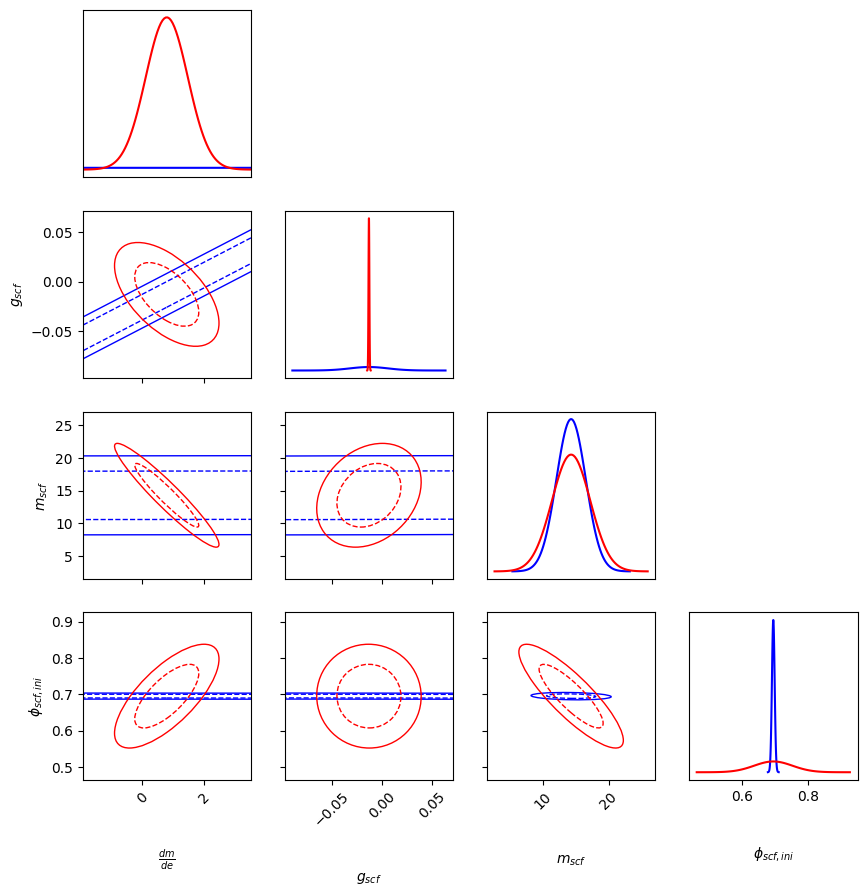

In [38]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
fishchips.util.plot_triangle(obs, cov, fig, ax, color = 'blue', labels = [r'$\frac{dm}{de}$', r'$g_{scf}$', r'$m_{scf}$', r'$\phi_{scf, ini}$'])
fishchips.util.plot_triangle(obs, F_new_inv, fig, ax, color = 'red', labels = [r'$\frac{dm}{de}$', r'$g_{scf}$', r'$m_{scf}$', r'$\phi_{scf, ini}$'])

cl and delta_cl for dm/de and g_scf， data points, 